In [1]:
# =====================================================================
# SEL 1: IMPORT LIBRARY & SETUP DATA
# =====================================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import joblib
import optuna

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from lightgbm import LGBMRegressor

# Menyembunyikan log Optuna yang terlalu panjang di terminal
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Konfigurasi MLflow
mlflow_tracking_uri = r"file:///D:/LENTERA_LAUT/mlruns"
mlflow.set_tracking_uri(mlflow_tracking_uri)

# Konfigurasi Visualisasi
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})

# Memuat Dataset
file_path = r"D:\LENTERA_LAUT\data\processed\final_dataset.csv"
df = pd.read_csv(file_path)

features = [
    "wave_height", "wind_speed_10m", "ocean_current_velocity", 
    "sea_surface_temperature", "precipitation", "visibility"
]
base_df = df.drop(columns=["time", "location", "id_location"], errors='ignore')

print(f"✅ Data siap: {len(base_df)} baris. Memulai Optuna Optimization...")

d:\LENTERA_LAUT\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Data siap: 13026 baris. Memulai Optuna Optimization...


In [2]:
# =====================================================================
# SEL 2: FUNGSI LEARNING CURVE UNTUK MODEL OPTUNA
# =====================================================================
def plot_learning_curve_optuna(estimator, title, X, y, cv=3, n_jobs=-1):
    plt.figure(figsize=(8, 5))
    plt.title(f"Learning Curve (Optuna Tuned) - {title}", fontsize=14, pad=15, fontweight='bold')
    plt.xlabel("Jumlah Data Pelatihan", fontsize=12)
    plt.ylabel("RMSE", fontsize=12)
    
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, 
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='neg_root_mean_squared_error'
    )
    
    train_scores_mean = -np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Plot Training Error
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="#F0AD4E")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="#F0AD4E", label="Training Error")
    
    # Plot Validation Error
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#4A7c59")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="#4A7c59", label="Validation Error")
    
    plt.legend(loc="best")
    plt.tight_layout()
    
    # Simpan plot
    reports_dir = r"D:\LENTERA_LAUT\reports\figures"
    os.makedirs(reports_dir, exist_ok=True)
    plot_path = os.path.join(reports_dir, f"lc_optuna_{title}.png")
    plt.savefig(plot_path, dpi=300)
    plt.close()
    
    return plot_path

print("✅ Fungsi grafik siap digunakan.")

✅ Fungsi grafik siap digunakan.


In [3]:
# =====================================================================
# SEL 3: OPTUNA BAYESIAN OPTIMIZATION & MLFLOW TRACKING
# =====================================================================
best_models_map = {
    "wave_height": "LinearRegression",
    "wind_speed_10m": "ExtraTrees",
    "ocean_current_velocity": "ExtraTrees",
    "sea_surface_temperature": "ExtraTrees",
    "precipitation": "RandomForest",
    "visibility": "LightGBM"
}

models_dir = r"D:\LENTERA_LAUT\models\saved_models"
os.makedirs(models_dir, exist_ok=True)

# Fungsi Objective untuk Optuna
def objective(trial, model_name, X_train_opt, y_train_opt):
    if model_name == "LinearRegression":
        fit_intercept = trial.suggest_categorical("fit_intercept", [True, False])
        model = LinearRegression(fit_intercept=fit_intercept)
        
    elif model_name == "ExtraTrees":
        n_estimators = trial.suggest_int("n_estimators", 100, 300)
        max_depth = trial.suggest_int("max_depth", 5, 12)
        min_samples_split = trial.suggest_int("min_samples_split", 5, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 2, 10)
        model = ExtraTreesRegressor(
            n_estimators=n_estimators, max_depth=max_depth, 
            min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf,
            random_state=42, n_jobs=-1
        )
        
    elif model_name == "RandomForest":
        n_estimators = trial.suggest_int("n_estimators", 100, 300)
        max_depth = trial.suggest_int("max_depth", 5, 12)
        min_samples_split = trial.suggest_int("min_samples_split", 5, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 2, 10)
        model = RandomForestRegressor(
            n_estimators=n_estimators, max_depth=max_depth, 
            min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf,
            random_state=42, n_jobs=-1
        )
        
    elif model_name == "LightGBM":
        n_estimators = trial.suggest_int("n_estimators", 100, 300)
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.1, log=True)
        max_depth = trial.suggest_int("max_depth", 3, 7)
        num_leaves = trial.suggest_int("num_leaves", 15, 60)
        reg_alpha = trial.suggest_float("reg_alpha", 0.1, 2.0)
        reg_lambda = trial.suggest_float("reg_lambda", 0.1, 2.0)
        model = LGBMRegressor(
            n_estimators=n_estimators, learning_rate=learning_rate,
            max_depth=max_depth, num_leaves=num_leaves,
            reg_alpha=reg_alpha, reg_lambda=reg_lambda,
            random_state=42, n_jobs=-1, verbose=-1
        )
    
    # Validasi Silang untuk mencari nilai RMSE terkecil
    scores = cross_val_score(model, X_train_opt, y_train_opt, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
    rmse = -scores.mean()
    return rmse

# Looping Utama Eksekusi
for target in features:
    model_name = best_models_map[target]
    print(f"\n{'='*50}")
    print(f"🧠 OPTUNA TUNING: {target.upper()} ({model_name})")
    
    # Cegah Data Leakage
    other_targets = [col for col in features if col != target]
    X = base_df.drop(columns=other_targets + [target], errors='ignore')
    y = base_df[target]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    mlflow.set_experiment(f"Optuna_Tuned_{target}")
    
    # Membuat Study Optuna (Tujuan: Meminimalkan RMSE)
    sampler = optuna.samplers.TPESampler(seed=42)
    study = optuna.create_study(sampler=sampler, direction="minimize")
    
    # Memulai pencarian dengan 15 iterasi cerdas
    print(f"   -> Sedang mencari parameter optimal (Bayesian Optimization)...")
    study.optimize(lambda trial: objective(trial, model_name, X_train, y_train), n_trials=15)
    
    best_params = study.best_params
    print(f"   -> Parameter Terbaik Ditemukan: {best_params}")
    
    with mlflow.start_run(run_name=f"Optuna_{model_name}_{target}"):
        
        # Merakit ulang model dengan parameter terbaik dari Optuna
        if model_name == "LinearRegression":
            final_model = LinearRegression(**best_params)
        elif model_name == "ExtraTrees":
            final_model = ExtraTreesRegressor(**best_params, random_state=42, n_jobs=-1)
        elif model_name == "RandomForest":
            final_model = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
        elif model_name == "LightGBM":
            final_model = LGBMRegressor(**best_params, random_state=42, n_jobs=-1, verbose=-1)
            
        # Latih model final dan prediksi data uji
        final_model.fit(X_train, y_train)
        final_preds = final_model.predict(X_test)
        
        final_rmse = np.sqrt(mean_squared_error(y_test, final_preds))
        final_r2 = r2_score(y_test, final_preds)
        print(f"   -> RMSE Akhir: {final_rmse:.4f} | R2 Akhir: {final_r2:.4f}")
        
        # Buat Learning Curve
        print("   -> Membuat visualisasi Learning Curve...")
        plot_path = plot_learning_curve_optuna(final_model, f"{model_name}_{target}", X_train, y_train)
        
        # Logging ke MLflow
        mlflow.log_params(best_params)
        mlflow.log_metric("Optuna_RMSE", final_rmse)
        mlflow.log_metric("Optuna_R2", final_r2)
        mlflow.log_artifact(plot_path)
        mlflow.sklearn.log_model(final_model, "model")
        
        # Export Model
        model_filename = os.path.join(models_dir, f"best_model_{target}.pkl")
        joblib.dump(final_model, model_filename)
        
        print(f"✅ Model cerdas berhasil diekspor ke: {model_filename}")

print("\n🎉 SELURUH PROSES OPTUNA TUNING SELESAI!")

d:\LENTERA_LAUT\venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
Traceback (most recent call last):
  File "d:\LENTERA_LAUT\venv\Lib\site-packages\mlflow\store\tracking\file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\LENTERA_LAUT\venv\Lib\site-packages\mlflow\store\tracking\file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\LENTERA_LAUT\ven


🧠 OPTUNA TUNING: WAVE_HEIGHT (LinearRegression)
   -> Sedang mencari parameter optimal (Bayesian Optimization)...
   -> Parameter Terbaik Ditemukan: {'fit_intercept': True}
   -> RMSE Akhir: 0.0134 | R2 Akhir: 0.9995
   -> Membuat visualisasi Learning Curve...


2026/06/06 18:52:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/06 18:52:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Traceback (most recent call last):
  File "d:\LENTERA_LAUT\venv\Lib\site-packages\mlflow\store\tracking\file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\LENTERA_LAUT\venv\Lib\site-packages\mlflow\store\tracking\file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

✅ Model cerdas berhasil diekspor ke: D:\LENTERA_LAUT\models\saved_models\best_model_wave_height.pkl

🧠 OPTUNA TUNING: WIND_SPEED_10M (ExtraTrees)
   -> Sedang mencari parameter optimal (Bayesian Optimization)...
   -> Parameter Terbaik Ditemukan: {'n_estimators': 175, 'max_depth': 12, 'min_samples_split': 16, 'min_samples_leaf': 7}
   -> RMSE Akhir: 1.9975 | R2 Akhir: 0.8361
   -> Membuat visualisasi Learning Curve...


2026/06/06 18:52:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/06 18:52:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Traceback (most recent call last):
  File "d:\LENTERA_LAUT\venv\Lib\site-packages\mlflow\store\tracking\file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\LENTERA_LAUT\venv\Lib\site-packages\mlflow\store\tracking\file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

...

✅ Model cerdas berhasil diekspor ke: D:\LENTERA_LAUT\models\saved_models\best_model_sea_surface_temperature.pkl

🧠 OPTUNA TUNING: PRECIPITATION (RandomForest)
   -> Sedang mencari parameter optimal (Bayesian Optimization)...
   -> Parameter Terbaik Ditemukan: {'n_estimators': 290, 'max_depth': 12, 'min_samples_split': 20, 'min_samples_leaf': 10}
   -> RMSE Akhir: 0.2161 | R2 Akhir: 0.4594
   -> Membuat visualisasi Learning Curve...


2026/06/06 18:54:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/06 18:54:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Traceback (most recent call last):
  File "d:\LENTERA_LAUT\venv\Lib\site-packages\mlflow\store\tracking\file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\LENTERA_LAUT\venv\Lib\site-packages\mlflow\store\tracking\file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

✅ Model cerdas berhasil diekspor ke: D:\LENTERA_LAUT\models\saved_models\best_model_precipitation.pkl

🧠 OPTUNA TUNING: VISIBILITY (LightGBM)
   -> Sedang mencari parameter optimal (Bayesian Optimization)...
   -> Parameter Terbaik Ditemukan: {'n_estimators': 191, 'learning_rate': 0.06097839109531514, 'max_depth': 3, 'num_leaves': 38, 'reg_alpha': 1.2255876808378807, 'reg_lambda': 0.18825578416799568}
   -> RMSE Akhir: 6288.2623 | R2 Akhir: 0.7585
   -> Membuat visualisasi Learning Curve...


2026/06/06 18:54:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/06 18:54:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Model cerdas berhasil diekspor ke: D:\LENTERA_LAUT\models\saved_models\best_model_visibility.pkl

🎉 SELURUH PROSES OPTUNA TUNING SELESAI!


In [5]:
# =====================================================================
# SEL 6: TABEL REKAPITULASI HASIL OPTIMASI (OPTUNA) DARI MLFLOW
# =====================================================================
import pandas as pd
import numpy as np
import mlflow
from IPython.display import display

features = [
    "wave_height", "wind_speed_10m", "ocean_current_velocity", 
    "sea_surface_temperature", "precipitation", "visibility"
]

rekap_optuna = []

print("Mengekstrak data tuning Optuna dari MLflow...\n")

for target in features:
    # Memanggil eksperimen yang berawalan "Optuna_Tuned_"
    experiment_name = f"Optuna_Tuned_{target}"
    experiment = mlflow.get_experiment_by_name(experiment_name)
    
    if experiment:
        # Mengambil semua run di dalam eksperimen ini
        runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])
        
        # Mengambil run dengan nilai RMSE terkecil
        if not runs.empty and 'metrics.Optuna_RMSE' in runs.columns:
            best_run = runs.loc[runs['metrics.Optuna_RMSE'].idxmin()]
            
            rekap_optuna.append({
                "Variabel Target": target,
                # Mengambil nama model dari kolom run_name dan membuang prefix/suffix-nya
                "Model Pemenang": best_run.get('tags.mlflow.runName', 'N/A').split('_')[1] if 'tags.mlflow.runName' in best_run else 'N/A',
                "RMSE (Optuna)": best_run.get('metrics.Optuna_RMSE', float('nan')),
                "R² (Optuna)": best_run.get('metrics.Optuna_R2', float('nan'))
            })

# Mengonversi daftar menjadi Pandas DataFrame
df_optuna = pd.DataFrame(rekap_optuna)

# Merapikan indeks agar dimulai dari 1
df_optuna.index = np.arange(1, len(df_optuna) + 1)

# Mempercantik format angka desimal (4 angka di belakang koma)
if not df_optuna.empty:
    df_optuna['RMSE (Optuna)'] = df_optuna['RMSE (Optuna)'].apply(lambda x: f"{x:.4f}")
    df_optuna['R² (Optuna)'] = df_optuna['R² (Optuna)'] .apply(lambda x: f"{x:.4f}")

# Menampilkan tabel
print("📊 TABEL REKAPITULASI PEMODELAN FINAL (OPTUNA TUNED)")
print("="*70)
display(df_optuna)

Traceback (most recent call last):
  File "d:\LENTERA_LAUT\venv\Lib\site-packages\mlflow\store\tracking\file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\LENTERA_LAUT\venv\Lib\site-packages\mlflow\store\tracking\file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\LENTERA_LAUT\venv\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1670, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\LENTERA_LAUT\venv\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1663, in _read_helper
    result = read_yaml(root, file_name)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\LENTERA_LAUT\venv\Lib\sit

Mengekstrak data tuning Optuna dari MLflow...



Traceback (most recent call last):
  File "d:\LENTERA_LAUT\venv\Lib\site-packages\mlflow\store\tracking\file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\LENTERA_LAUT\venv\Lib\site-packages\mlflow\store\tracking\file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\LENTERA_LAUT\venv\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1670, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\LENTERA_LAUT\venv\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1663, in _read_helper
    result = read_yaml(root, file_name)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\LENTERA_LAUT\venv\Lib\sit

📊 TABEL REKAPITULASI PEMODELAN FINAL (OPTUNA TUNED)


,Variabel Target,Model Pemenang,RMSE (Optuna),R² (Optuna)
1,wave_height,LinearRegression,0.0134,0.9995
2,wind_speed_10m,ExtraTrees,1.9975,0.8361
3,ocean_current_velocity,ExtraTrees,0.1892,0.9767
4,sea_surface_temperature,ExtraTrees,0.0503,0.9986
5,precipitation,RandomForest,0.2161,0.4594
6,visibility,LightGBM,6288.2623,0.7585


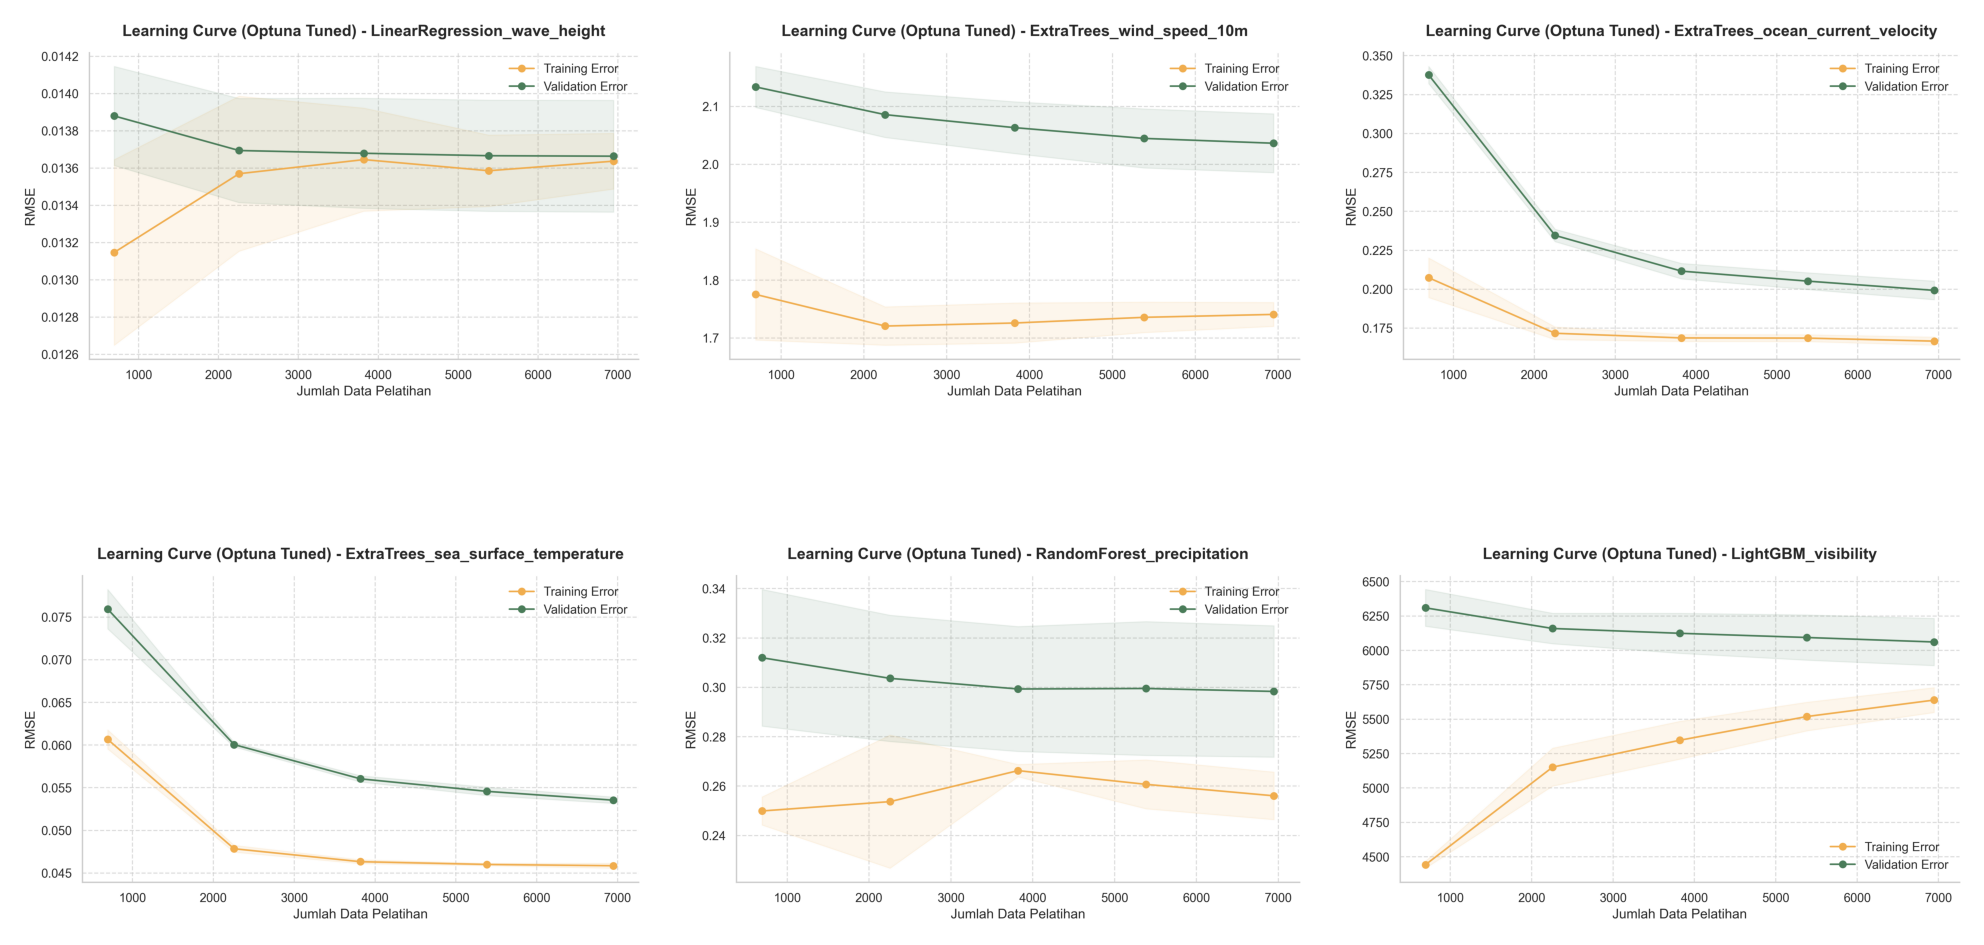

In [4]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Pemetaan target dengan algoritma pemenang
best_models_map = {
    "wave_height": "LinearRegression",
    "wind_speed_10m": "ExtraTrees",
    "ocean_current_velocity": "ExtraTrees",
    "sea_surface_temperature": "ExtraTrees",
    "precipitation": "RandomForest",
    "visibility": "LightGBM"
}

# Direktori tempat gambar Optuna disimpan
figures_dir = r"D:\LENTERA_LAUT\reports\figures"

# Membuat kanvas besar
plt.figure(figsize=(20, 12))

# Looping untuk menampilkan setiap gambar hasil tuning
for i, (target, model_name) in enumerate(best_models_map.items(), 1):
    file_name = f"lc_optuna_{model_name}_{target}.png"
    file_path = os.path.join(figures_dir, file_name)
    
    plt.subplot(2, 3, i)
    if os.path.exists(file_path):
        img = mpimg.imread(file_path)
        plt.imshow(img)
        plt.axis('off')
    else:
        plt.text(0.5, 0.5, f"❌ Gambar tidak ditemukan:\n{file_name}", 
                 ha='center', va='center', fontsize=12, color='red')
        plt.axis('off')

plt.tight_layout()
plt.show()